In [1]:
import numpy as np
from scipy.optimize import minimize
import pandas as pd
import GPy
from scipy.special import expit
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.spatial import distance
import statsmodels.api as sm
import warnings
import numpy as np
from scipy.optimize import differential_evolution
from scipy.stats import rankdata
from sklearn.cross_decomposition import CCA
import math
import copy
from math import log
from collections import Counter
import pickle
from sklearn.linear_model import Lasso
warnings.filterwarnings("ignore")

In [2]:
# Read beta back from the file
beta_star = np.load('beta_star.npy')
print("beta_star:", beta_star)
n_features = len(beta_star)

np.sum(beta_star[beta_star > 0])

beta_star: [ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          4.6053456   0.          0.         -6.58538114  0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  4.03732014  0.          0.          0.          0.          0.
  0.         -8.46546442  0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          5.69413687  0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          

14.336802617338863

In [6]:
from sklearn.linear_model import Lasso

def lasso_stochastic_bandit(phi, T, C_max_wave, L, error_std, Y_t, X_t, beta_star):
    """
    Implements the preconditioning LASSO bandit algorithm.

    Args:
        phi (float): Regularization parameter for optimization.
        T (int): Total time steps.
        C_max_wave (float): F_t matrix eigenvalue constraint.
        L (float): Upper limit for X values.
        error_std (float): Standard deviation for error term.
        Y_t (array): Initial response vector.
        X_t (array): Initial feature matrix.
        beta_star (array): True coefficient vector for simulation.

    Returns:
        Y_t, X_t: Updated response vector and feature matrix.
    """
    n_features = X_t.shape[1]  # Number of features

    Y_t_exp = Y_t

    l_2_error_parameter = np.array([])

    for tau in range(len(Y_t), T):
        # Compute lambda for LASSO
        lamada = 2 * error_std * C_max_wave * L * np.sqrt(2 * (2 * np.log(tau) + np.log(n_features)) / tau)

        # Perform LASSO regression with lambda using Y_t_tran and X_t_tran
        lasso = Lasso(alpha=lamada, fit_intercept=False)
        lasso.fit(X_t, Y_t)  # Fit the model to get beta estimates
        beta_esti = lasso.coef_  # Estimated beta values
        print(f"parameter square error:{np.sqrt(sum((beta_esti - beta_star)**2))}")
        s_esti = np.count_nonzero(beta_esti)  # Number of non-zero coefficients

        # Perform optimization to find X_max
        # Check if expected Y_t has not changed for 20 iterations
        if len(Y_t_exp) >= 20 and np.all(Y_t_exp[-20:] == Y_t_exp[-1]):
            # Keep X_max unchanged
            X_max = X_t[-1]
        else:
            if len(Y_t_exp) <= 600:
                # Perform optimization to find X_max
                X_max = optimization(beta_esti, s_esti, X_t, L, lamada, phi, tau)
            else:
                X_max = optimization_no_variance(beta_esti, s_esti, X_t, L, lamada, tau)

        # Generate Y_max based on true beta_star
        Y_max = beta_star @ X_max + np.random.normal(0, error_std, 1)

        # Generate Y_max based on true beta_star
        Y_max_exp = beta_star @ X_max
    
        print(f"time {tau}: mean reward {beta_star @ X_max}")
        #print(f"time {tau}: action {X_max}")

        l_2_error_parameter = np.append(l_2_error_parameter, np.sqrt(sum((beta_esti - beta_star)**2)))

        # Append X_max and Y_max to X_t and Y_t
        Y_t = np.append(Y_t, Y_max)
        X_t = np.vstack([X_t, X_max])

        Y_t_exp = np.append(Y_t_exp, Y_max_exp)

    return Y_t, X_t, Y_t_exp, l_2_error_parameter


In [7]:
def optimization(beta_esti, s_esti, X_t, L, lamada, phi, tau):
    """
    Perform optimization using a hill-climbing algorithm under given constraints.

    Args:
        beta_esti (numpy array): Estimated coefficients (beta).
        s_esti (float): Estimated parameter for scaling.
        X_t (numpy array): Existing feature matrix.
        lamada (float): Regularization parameter.
        phi (float): Parameter for constraint.
        C_max_wave (float): Constraint for F_t matrix eigenvalue.
        t (int): Time step or scaling factor.
        max_iterations (int): Maximum number of iterations for the algorithm.

    Returns:
        numpy array: Optimized X_max vector.
    """
    # Define the objective function
    # Define the objective function
    def objective(X_max):
        X_max = np.array(X_max)
        sqrt_term = np.sqrt(X_max @ np.linalg.pinv((1 / tau) * (X_t.T @ X_t)) @ X_max.reshape(-1, 1))
        constant = (4 * np.sqrt(s_esti) * lamada / phi)
        return -(beta_esti @ X_max + constant * sqrt_term)  # Negate for maximization
    
    # Initial guess for X_max
    X_max_initial = np.random.uniform(0, L, size=len(beta_esti))
    
    # Set bounds for each variable in X_max [0, L]
    bounds = [(0, L) for _ in range(len(beta_esti))]
    
    # Perform optimization
    result = minimize(objective, X_max_initial, bounds=bounds)
    
    # Output the result
    if result.success:
        X_max_optimal = result.x
    else:
        X_max_optimal = X_max_initial
        print("Optimization failed:", result.message)


    return X_max_optimal


In [8]:
def optimization_no_variance(beta_esti, s_esti, X_t, L, lamada, tau):

    # Define the objective function
    # Define the objective function
    def objective(X_max):
        X_max = np.array(X_max)
        return -(beta_esti @ X_max)  # Negate for maximization
    
    # Initial guess for X_max
    X_max_initial = np.random.uniform(0, L, size=len(beta_esti))
    
    # Set bounds for each variable in X_max [0, L]
    bounds = [(0, L) for _ in range(len(beta_esti))]
    
    # Perform optimization
    result = minimize(objective, X_max_initial, bounds=bounds)
    
    # Output the result
    if result.success:
        X_max_optimal = result.x
    else:
        print("Optimization failed:", result.message)


    return X_max_optimal

# Lasso Stochastic Bandit

In [9]:
def while_lasso_stochastic_bandit(beta_star):
    error_std = 1
    phi = 10
    C_max_wave = 1
    t = 2
    T = 1000 + t
    L = 1
    # Generate X where the first column is 1, and the remaining columns are random values
    X_t = np.ones((t, n_features))  # Start with an array of ones
    X_t[:, 1:] = np.random.uniform(0, L, (t, n_features - 1))  # Fill the remaining columns with random values
    
    # Generate random error term
    error_t = np.random.normal(0, error_std, t)
    
    # Compute Y = X @ beta_star + error_t
    Y_t = X_t @ beta_star + error_t
    
    Y_T, X_T, Y_t_exp, l_2_error_parameter = lasso_stochastic_bandit(phi, T, C_max_wave, L, error_std, Y_t, X_t, beta_star)

    return Y_t_exp, l_2_error_parameter

In [10]:
cumulative_regre_times = []
l_2_error_parameter_times = []

# Run the experiment 10 times
for times in range(10):
    # Ensure beta_star and `t` are properly initialized
    Y_t_exp, l_2_error_parameter = while_lasso_stochastic_bandit(beta_star)  # Replace with the actual function
    Y_t_to_T = Y_t_exp
    
    # Calculate instantaneous regret
    instantaneous_regret = np.sum(beta_star[beta_star > 0]) - Y_t_to_T
    instantaneous_regret = np.where(instantaneous_regret < 0.002, 0, instantaneous_regret)  # Threshold adjustment

    # Calculate cumulative regret
    cumulative_regret = np.cumsum(instantaneous_regret)

    # Append results to the list
    cumulative_regre_times.append(cumulative_regret)
    l_2_error_parameter_times.append(l_2_error_parameter)

# The results `cumulative_regre_times` and `l_2_error_parameter_times` now store the outcomes of all experiments.

parameter square error:13.600135637512361
time 2: mean reward 0.6927610812059051
parameter square error:13.600135637512361
time 3: mean reward 7.383920724774557
parameter square error:13.600135637512361
time 4: mean reward 4.161382776212184
parameter square error:13.600135637512361
time 5: mean reward 4.587925517426546
parameter square error:13.600135637512361
time 6: mean reward 0.8752774364531062
parameter square error:13.600135637512361
time 7: mean reward -9.785813865792447
parameter square error:13.600135637512361
time 8: mean reward -8.312108539999016
parameter square error:13.600135637512361
time 9: mean reward 2.9221128546680135
parameter square error:13.600135637512361
time 10: mean reward -0.688783625204791
parameter square error:13.600135637512361
time 11: mean reward -3.4880381554611724
parameter square error:13.600135637512361
time 12: mean reward -5.033091353704285
parameter square error:13.600135637512361
time 13: mean reward -0.6939543835741988
parameter square error:13

In [11]:
# Convert lists to NumPy arrays for easier computation
cumulative_regret_times = np.array(cumulative_regre_times)
l_2_error_parameter_times = np.array(l_2_error_parameter_times)

# Calculate the mean and standard deviation along the "times" axis
cumulative_regret_mean = np.mean(cumulative_regret_times, axis=0)
cumulative_regret_std = np.std(cumulative_regret_times, axis=0)

l_2_error_parameter_mean = np.mean(l_2_error_parameter_times, axis=0)
l_2_error_parameter_std = np.std(l_2_error_parameter_times, axis=0)

# Print or use the results as needed
print("Cumulative Regret Mean:", cumulative_regret_mean)
print("Cumulative Regret Std:", cumulative_regret_std)
print("L2 Error Parameter Mean:", l_2_error_parameter_mean)
print("L2 Error Parameter Std:", l_2_error_parameter_std)

Cumulative Regret Mean: [  13.23138761   31.37262901   46.3786348  ... 3230.46384729 3230.46384729
 3230.46384729]
Cumulative Regret Std: [   3.33010268    6.79421253    7.19933925 ... 1255.40781998 1255.40781998
 1255.40781998]
L2 Error Parameter Mean: [13.61812173 13.60341082 13.60110196 13.61012308 13.60138506 13.63094433
 13.61393963 13.61055595 13.61043474 13.59350234 13.50168459 13.51439001
 13.47483974 13.52751858 13.53751161 13.5068494  13.51456419 13.52603086
 13.5025434  13.51387168 13.51923032 13.56600667 13.56870744 13.55271065
 13.55454791 13.55094876 13.54651132 13.53239303 13.54901055 13.54808442
 13.52223279 13.51062565 13.51365496 13.50858311 13.5157648  13.52038245
 13.52002277 13.52442236 13.53896334 13.53271233 13.5342974  13.46528145
 13.47155307 13.44675727 13.43496539 13.3955792  13.38658189 13.39713891
 13.400209   13.3631298  13.32885514 13.3388616  13.34586686 13.33838864
 13.33722808 13.32827555 13.30166352 13.28646542 13.29171996 13.26748228
 13.19929536 13.

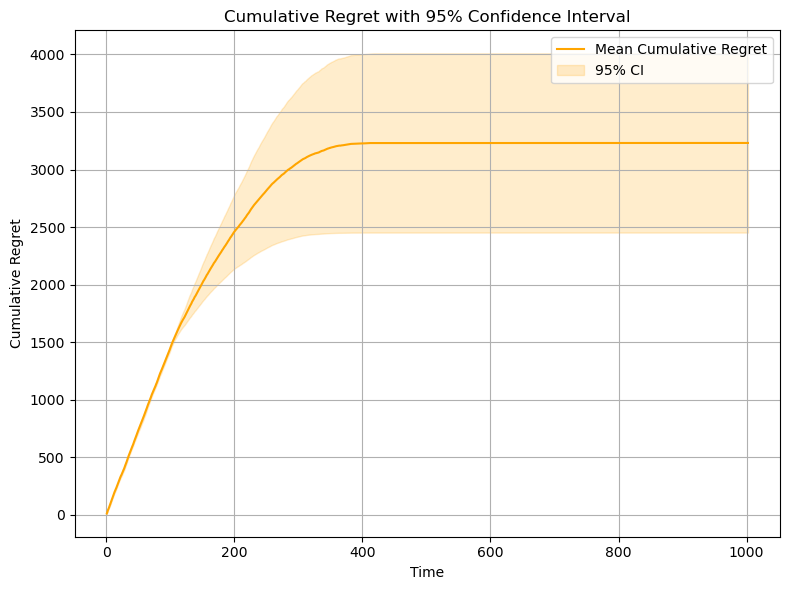

In [12]:
# Calculate the 95% confidence interval for the cumulative regret
lower_bound = cumulative_regret_mean - 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))
upper_bound = cumulative_regret_mean + 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))

# Plot the mean cumulative regret with confidence intervals
plt.figure(figsize=(8, 6))
time_steps = range(1, len(cumulative_regret_mean) + 1)

# Plot the mean line
plt.plot(time_steps, cumulative_regret_mean, label='Mean Cumulative Regret', color='orange')

# Fill the 95% confidence interval
plt.fill_between(time_steps, lower_bound, upper_bound, color='orange', alpha=0.2, label='95% CI')

# Add title, labels, and legend
plt.title('Cumulative Regret with 95% Confidence Interval')
plt.xlabel('Time')
plt.ylabel('Cumulative Regret')
plt.grid()
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


In [13]:
np.save('cumulative_regret_lasso-stochastic-bandit-d100-s5_10times.npy', cumulative_regret_times)
np.save('l_2_error_parameter_lasso-stochastic-bandit-d100-s5_10times.npy', l_2_error_parameter_times)

# SA Lasso Bandit

In [14]:
from sklearn.linear_model import Lasso

def SA_lasso_bandit_no_variance(T, C_max_wave, L, error_std, Y_t, X_t, beta_star):

    n_features = X_t.shape[1]  # Number of features

    Y_t_exp = Y_t

    l_2_error_parameter = np.array([])

    for tau in range(len(Y_t), T):
        # Compute lambda for LASSO
        lamada = 2 * error_std * C_max_wave * L * np.sqrt(2 * (2 * np.log(tau) + np.log(n_features)) / tau)

        # Perform LASSO regression with lambda using Y_t_tran and X_t_tran
        lasso = Lasso(alpha=lamada, fit_intercept=False)
        lasso.fit(X_t, Y_t)  # Fit the model to get beta estimates
        beta_esti = lasso.coef_  # Estimated beta values
        print(f"parameter square error:{np.sqrt(sum((beta_esti - beta_star)**2))}")
        s_esti = np.count_nonzero(beta_esti)  # Number of non-zero coefficients

        # Perform optimization to find X_max
        # Check if expected Y_t has not changed for 20 iterations
        if len(Y_t_exp) >= 20 and np.all(Y_t_exp[-20:] == Y_t_exp[-1]):
            # Keep X_max unchanged
            X_max = X_t[-1]
        else:
            # Perform optimization to find X_max
            X_max = optimization_no_variance(beta_esti, s_esti, X_t, L, lamada, tau)

        # Generate Y_max based on true beta_star
        Y_max_exp = beta_star @ X_max
        Y_max = beta_star @ X_max + np.random.normal(0, error_std, 1)
        
        print(f"time {tau}: mean reward {beta_star @ X_max}")
        #print(f"time {tau}: action {X_max}")

        l_2_error_parameter = np.append(l_2_error_parameter, np.sqrt(sum((beta_esti - beta_star)**2)))

        # Append X_max and Y_max to X_t and Y_t
        Y_t = np.append(Y_t, Y_max)
        X_t = np.vstack([X_t, X_max])

        Y_t_exp = np.append(Y_t_exp, Y_max_exp)
        

    return Y_t, X_t, Y_t_exp, l_2_error_parameter

In [15]:
def optimization_no_variance(beta_esti, s_esti, X_t, L, lamada, tau):

    # Define the objective function
    # Define the objective function
    def objective(X_max):
        X_max = np.array(X_max)
        return -(beta_esti @ X_max)  # Negate for maximization
    
    # Initial guess for X_max
    X_max_initial = np.random.uniform(0, L, size=len(beta_esti))
    
    # Set bounds for each variable in X_max [0, L]
    bounds = [(0, L) for _ in range(len(beta_esti))]
    
    # Perform optimization
    result = minimize(objective, X_max_initial, bounds=bounds)
    
    # Output the result
    if result.success:
        X_max_optimal = result.x
    else:
        print("Optimization failed:", result.message)


    return X_max_optimal


In [16]:
def while_SA_lasso_bandit_no_variance(beta_star):
    error_std = 1
    phi = 50
    C_max_wave = 1
    t = 2
    T = 1000 + t
    L = 1
    # Generate X where the first column is 1, and the remaining columns are random values
    X_t = np.ones((t, n_features))  # Start with an array of ones
    X_t[:, 1:] = np.random.uniform(0, L, (t, n_features - 1))  # Fill the remaining columns with random values
    
    # Generate random error term
    error_t = np.random.normal(0, error_std, t)
    
    # Compute Y = X @ beta_star + error_t
    Y_t = X_t @ beta_star + error_t
    
    Y_T_no, X_T_no, Y_t_exp_no, l_2_error_parameter = SA_lasso_bandit_no_variance(T, C_max_wave, L, error_std, Y_t, X_t, beta_star)

    return Y_t_exp_no, l_2_error_parameter

In [17]:
cumulative_regre_times = []
l_2_error_parameter_times = []

# Run the experiment 10 times
for times in range(10):
    # Ensure beta_star and `t` are properly initialized
    Y_t_exp, l_2_error_parameter = while_SA_lasso_bandit_no_variance(beta_star)  # Replace with the actual function
    Y_t_to_T = Y_t_exp
    
    # Calculate instantaneous regret
    instantaneous_regret = np.sum(beta_star[beta_star > 0]) - Y_t_to_T
    instantaneous_regret = np.where(instantaneous_regret < 0.002, 0, instantaneous_regret)  # Threshold adjustment

    # Calculate cumulative regret
    cumulative_regret = np.cumsum(instantaneous_regret)

    # Append results to the list
    cumulative_regre_times.append(cumulative_regret)
    l_2_error_parameter_times.append(l_2_error_parameter)

parameter square error:13.85570177884916
time 2: mean reward -0.20642626323469537
parameter square error:13.649159980608822
time 3: mean reward -2.5915704559114947
parameter square error:13.470064524237632
time 4: mean reward 6.148551435898073
parameter square error:13.600135637512361
time 5: mean reward -9.693472799288328
parameter square error:12.707409600899174
time 6: mean reward 5.277276898003295
parameter square error:13.016770448162177
time 7: mean reward 5.717420282397885
parameter square error:13.322022579534806
time 8: mean reward 6.986171311389489
parameter square error:13.600135637512361
time 9: mean reward 0.7785452044111523
parameter square error:13.600135637512361
time 10: mean reward 5.0891653486455155
parameter square error:13.600135637512361
time 11: mean reward 1.7595285943134944
parameter square error:13.600135637512361
time 12: mean reward -2.170547412179018
parameter square error:13.600135637512361
time 13: mean reward -3.6148808483212953
parameter square error:13

In [18]:
# Convert lists to NumPy arrays for easier computation
cumulative_regret_times = np.array(cumulative_regre_times)
l_2_error_parameter_times = np.array(l_2_error_parameter_times)

# Calculate the mean and standard deviation along the "times" axis
cumulative_regret_mean = np.mean(cumulative_regret_times, axis=0)
cumulative_regret_std = np.std(cumulative_regret_times, axis=0)

l_2_error_parameter_mean = np.mean(l_2_error_parameter_times, axis=0)
l_2_error_parameter_std = np.std(l_2_error_parameter_times, axis=0)

# Print or use the results as needed
print("Cumulative Regret Mean:", cumulative_regret_mean)
print("Cumulative Regret Std:", cumulative_regret_std)
print("L2 Error Parameter Mean:", l_2_error_parameter_mean)
print("L2 Error Parameter Std:", l_2_error_parameter_std)

Cumulative Regret Mean: [  18.00493664   35.38814345   50.7860562  ... 6601.79226124 6602.13260621
 6602.88558911]
Cumulative Regret Std: [  1.85051544   4.23886636   5.93010221 ... 717.22995792 717.65738626
 718.74719981]
L2 Error Parameter Mean: [13.63542105 13.62519436 13.59344172 13.60066361 13.51086303 13.54179912
 13.57232433 13.60013564 13.60013564 13.60013564 13.60013564 13.60013564
 13.60013564 13.60013564 13.60013564 13.60013564 13.60013564 13.60013564
 13.60013564 13.60013564 13.60013564 13.60013564 13.60013564 13.60013564
 13.60013564 13.60013564 13.60013564 13.60013564 13.60013564 13.60013564
 13.60013564 13.60013564 13.60013564 13.60013564 13.60013564 13.60013564
 13.60013564 13.60013564 13.60013564 13.60013564 13.60013564 13.60013564
 13.60013564 13.59237369 13.59535837 13.59832502 13.60013564 13.60013564
 13.60013564 13.60013564 13.60013564 13.60013564 13.60013564 13.60013564
 13.59814943 13.60013564 13.60013564 13.60013564 13.60013564 13.60013564
 13.60013564 13.600135

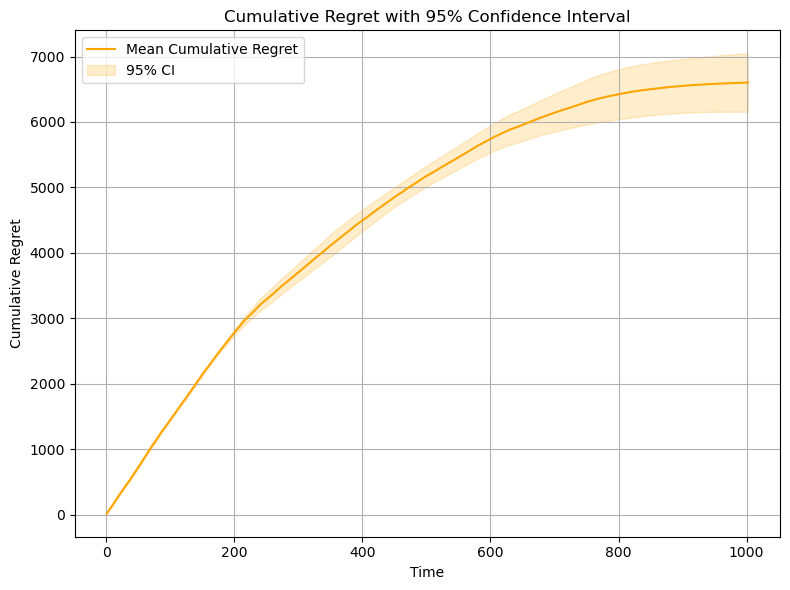

In [19]:
# Calculate the 95% confidence interval for the cumulative regret
lower_bound = cumulative_regret_mean - 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))
upper_bound = cumulative_regret_mean + 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))

# Plot the mean cumulative regret with confidence intervals
plt.figure(figsize=(8, 6))
time_steps = range(1, len(cumulative_regret_mean) + 1)

# Plot the mean line
plt.plot(time_steps, cumulative_regret_mean, label='Mean Cumulative Regret', color='orange')

# Fill the 95% confidence interval
plt.fill_between(time_steps, lower_bound, upper_bound, color='orange', alpha=0.2, label='95% CI')

# Add title, labels, and legend
plt.title('Cumulative Regret with 95% Confidence Interval')
plt.xlabel('Time')
plt.ylabel('Cumulative Regret')
plt.grid()
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [21]:
np.save('cumulative_regret_SA-lasso-bandit-d100-s5_10times.npy', cumulative_regret_times)
np.save('l_2_error_parameter_SA-lasso-bandit-d100-s5_10times.npy', l_2_error_parameter_times)